# 02. Gradient Boosting (XGBoost, LightGBM)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply boosting (e.g. AdaBoost, gradient boosting)
- Compare with bagging and single models
- Tune and interpret ensemble performance

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 3, lesson 06 "Ensemble Techniques" — the boosting idea, now in its production form (XGBoost/LightGBM) with tuning.

**Used later in:** Course 12 (AIAT 126) — Unit 3, where gradient boosting is a standard strong baseline for tabular project data.

---


## 🌍 A real case: 17 of 29 Kaggle winners

Chen and Guestrin opened the XGBoost paper (KDD 2016) with a count, not a claim: among the **29
challenge-winning solutions published on Kaggle's blog during 2015, 17 used XGBoost** — eight of them
used XGBoost and nothing else — while the second most popular method, deep neural networks, appeared
in 11. In KDDCup 2015, **every team in the top ten** used it. That count is why gradient boosting
became the default first thing to try on tabular data, and it has stayed there for a decade.

**❗ Why this lesson exists — and the price boosting charges.** Boosting fits each new tree to what the
previous trees got wrong. That is what makes it strong, and it is also what makes it the family most
able to memorise. Read the two columns below together, not separately:

| Model | Train | Test | Gap |
|---|---|---|---|
| Random Forest (bagging) | 0.5394 | 0.5370 | 0.002 |
| XGBoost (boosting) | 0.6541 | 0.5720 | **0.082** |
| LightGBM (boosting) | 0.6393 | 0.5695 | 0.070 |

Boosting bought 3.5 points of test accuracy on this data — and brought an eight-point overfitting gap
that somebody now has to manage with early stopping every time the model is retrained.

**State of the field (2026).** The tabular default is genuinely contested now. Grinsztajn et al.
(arXiv 2207.08815) set out why tree ensembles still beat deep networks on medium-sized tabular data,
while tabular foundation models — TabPFN-2.5 (arXiv 2511.08667), TabPFN-3 (arXiv 2605.13986) — report
matching AutoGluon-class accuracy and beating *tuned* tree ensembles, with no per-dataset training.
Benchmark against one before assuming XGBoost wins your problem. The **🔭 State of the field (2026)** box at the end of this notebook gives the reported numbers, what they cost to reproduce, and what they change in your workflow.


# 02. Gradient Boosting (XGBoost, LightGBM)

---

## The Story: Learning from Mistakes

Imagine you're learning to play chess. **Before** boosting, you play many games independently (like Random Forest). **After** boosting, you learn from each game: focus on positions where you made mistakes, get better each time - much more effective!

Same with machine learning: **Before** boosting, models are trained independently. **After** boosting, each new model focuses on mistakes of previous models - sequential improvement leads to excellent performance!

---

## Why Boosting Matters

Boosting algorithms are among the best ML models:
- **State-of-the-Art Performance**: Often achieve best results in competitions
- **Sequential Learning**: Each model learns from previous mistakes
- **XGBoost**: Extremely popular, fast, and powerful
- **LightGBM**: Even faster than XGBoost, great for large datasets
- **Industry Standard**: Used in production systems worldwide

---

## 🌍 Real-World Applications

**XGBoost and LightGBM are used in MANY industries for state-of-the-art performance!** Here's where you'll find them:

### 🏆 Machine Learning Competitions (Kaggle, etc.)
- **Kaggle Competitions**: XGBoost/LightGBM often win competitions → best performance
- **Data Science Competitions**: Used by top teams worldwide
- **Hackathons**: Go-to algorithm for quick, high-performance solutions
- **Benchmarking**: Used to benchmark against other algorithms

### 💰 Finance & Banking Sector
- **Credit Scoring**: XGBoost predicts loan defaults with high accuracy → optimize lending decisions
- **Fraud Detection**: LightGBM detects fraudulent transactions → real-time fraud prevention
- **Algorithmic Trading**: XGBoost predicts stock movements → automated trading systems
- **Risk Assessment**: XGBoost assesses investment risks → portfolio management
- **Insurance Claims**: XGBoost predicts claim amounts → optimize insurance pricing
- **Customer Lifetime Value**: XGBoost predicts customer value → marketing optimization

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: XGBoost diagnoses diseases from patient data → improve diagnosis accuracy
- **Drug Discovery**: XGBoost identifies effective drug compounds → accelerate drug development
- **Medical Imaging**: XGBoost classifies medical images → assist radiologists
- **Patient Risk Stratification**: XGBoost predicts patient outcomes → optimize treatment
- **Clinical Decision Support**: XGBoost helps doctors make decisions → improve patient care
- **Epidemiology**: XGBoost predicts disease spread → public health planning

### 📊 Marketing & E-commerce Sector
- **Recommendation Systems**: XGBoost powers product recommendations → increase sales
- **Customer Churn**: LightGBM predicts churn → retain customers
- **Ad Click Prediction**: XGBoost predicts ad clicks → optimize ad spending
- **Price Optimization**: XGBoost optimizes pricing → maximize revenue
- **Customer Segmentation**: XGBoost segments customers → targeted marketing
- **Sales Forecasting**: XGBoost predicts sales → inventory management

### 🏭 Manufacturing & Quality Control
- **Quality Prediction**: XGBoost predicts product quality → reduce defects
- **Predictive Maintenance**: LightGBM predicts equipment failures → prevent downtime
- **Defect Detection**: XGBoost identifies defects → quality control
- **Supply Chain Optimization**: XGBoost optimizes supply chains → reduce costs
- **Production Optimization**: XGBoost optimizes production → increase efficiency
- **Energy Management**: XGBoost optimizes energy usage → reduce costs

### 🚗 Transportation & Logistics
- **Route Optimization**: XGBoost optimizes delivery routes → reduce delivery time
- **Demand Forecasting**: LightGBM predicts demand → optimize inventory
- **Fleet Management**: XGBoost optimizes fleet operations → reduce costs
- **Traffic Prediction**: XGBoost predicts traffic → optimize routes
- **Maintenance Scheduling**: XGBoost schedules maintenance → prevent failures

### 🔬 Scientific Research & Data Analysis
- **Genomics**: XGBoost identifies important genes → disease research
- **Climate Modeling**: XGBoost predicts climate patterns → environmental planning
- **Material Science**: XGBoost discovers new materials → innovation
- **Astronomy**: XGBoost classifies celestial objects → space research
- **Epidemiology**: XGBoost models disease spread → public health

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Emergency Response Optimization**: XGBoost predicts emergency needs → optimize resource allocation → faster response times → **GDI: Emergency Response**
- **Threat Detection Systems**: XGBoost detects security threats with high accuracy → critical for national security → **GDI: Counter-Espionage, Terrorism Detection**
- **Traffic Flow Optimization**: LightGBM predicts traffic patterns → optimize traffic signals → reduce congestion → **GDI: Traffic Management**
- **Crime Prediction**: XGBoost predicts crime hotspots → optimize patrol routes → crime prevention → **GDI: Internal Intelligence**
- **Border Security Screening**: XGBoost classifies border crossings → identify threats → border control → **GDI: Border Security**
- **Surveillance Alert Systems**: LightGBM classifies surveillance alerts → reduce false positives → security monitoring → **GDI: Internal Intelligence**
- **Traffic Violation Detection**: XGBoost detects traffic violations → automated enforcement → **GDI: Traffic Management**
- **Personnel Security Assessment**: XGBoost assesses security clearance → optimize internal security → **GDI: Internal Intelligence**
- **Identity Verification**: XGBoost verifies identities → high-accuracy verification → **GDI: Airport Security**
- **Traffic Accident Prediction**: XGBoost predicts accident risk → optimize traffic management → **GDI: Traffic Management**
- **Financial Crime Detection**: XGBoost detects financial fraud → optimize investigations → **GDI: Financial Investigations, Terrorism Financing**
- **Cyber Threat Detection**: XGBoost detects cyber attacks → optimize network security → **GDI: Cyber Threats**

### 💡 Why XGBoost/LightGBM are Industry Standards:
- **Best Performance**: Often achieve highest accuracy
- **Fast Training**: LightGBM is very fast (important for large datasets)
- **Handles Missing Values**: Automatically handles missing data (convenient!)
- **Feature Importance**: Shows which features matter most
- **Production Ready**: Used in production systems worldwide
- **Competition Winners**: Often win ML competitions

### 📈 When to Use XGBoost vs LightGBM:
✅ **Use XGBoost when:**
- Need best possible performance
- Have medium to large datasets
- Want industry-standard solution
- Need feature importance
- Working on competitions or production

✅ **Use LightGBM when:**
- Have very large datasets (millions of rows)
- Need faster training than XGBoost
- Have limited computational resources
- Need to train quickly
- Working with big data

✅ **Use Both:**
- Try both and compare performance
- Ensemble both for even better results
- Use LightGBM for speed, XGBoost for accuracy

### 🎯 Real-World Success Stories:
- **Kaggle Competitions**: XGBoost/LightGBM used by most winning teams
- **Netflix Recommendations**: Uses boosting for recommendations
- **Amazon**: Uses XGBoost for product recommendations
- **Banks**: Use XGBoost for credit scoring and fraud detection
- **Healthcare**: Use XGBoost for medical diagnosis

---

## Learning Objectives
1. Build XGBoost models
2. Build LightGBM models
3. Understand how boosting differs from bagging
4. Compare boosting with Random Forest
5. Interpret feature importance in boosting models
6. Know when to use each boosting algorithm


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build boosting models

import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For visualizations
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.ensemble import RandomForestClassifier  # For comparison (bagging)
from sklearn.metrics import (
    accuracy_score,        # Classification accuracy
    classification_report,  # Comprehensive metrics
    confusion_matrix       # Confusion matrix (for multi-class)
)
# Note: ROC curves removed - they only work for binary classification
# We use confusion matrices for multi-class (3 classes: EMS, Fire, Traffic)
# Removed make_classification - using real Breast Cancer dataset instead

print("✅ Libraries imported successfully!")
print("\n📚 Key Boosting Concepts:")
print("   - Boosting: Sequential ensemble (each model learns from previous mistakes)")
print("   - Bagging: Parallel ensemble (Random Forest - models trained independently)")
print("   - XGBoost: Extreme Gradient Boosting (very popular, fast, powerful)")
print("   - LightGBM: Light Gradient Boosting Machine (faster than XGBoost)")
print("   - Learning Rate: Controls how much each new model contributes")
print("\n   💡 Boosting vs Bagging:")
print("   - Bagging (RF): Models trained in parallel, then averaged")
print("   - Boosting: Models trained sequentially, each focuses on mistakes")


✅ Libraries imported successfully!

📚 Key Boosting Concepts:
   - Boosting: Sequential ensemble (each model learns from previous mistakes)
   - Bagging: Parallel ensemble (Random Forest - models trained independently)
   - XGBoost: Extreme Gradient Boosting (very popular, fast, powerful)
   - LightGBM: Light Gradient Boosting Machine (faster than XGBoost)
   - Learning Rate: Controls how much each new model contributes

   💡 Boosting vs Bagging:
   - Bagging (RF): Models trained in parallel, then averaged
   - Boosting: Models trained sequentially, each focuses on mistakes


In [2]:
# Try to import XGBoost and LightGBM
# These are external libraries (not part of sklearn).
# If either is missing, the notebook still runs and the comparison
# simply includes only the models that actually trained.

import sys

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"Python: {sys.executable}")
print(f"Version: {sys.version.split()[0]}")
print("=" * 60)
print()

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print(f"XGBoost imported successfully (version {xgb.__version__})")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available - its sections will be skipped")
    print(f"   Reason: {type(e).__name__}: {str(e)[:120]}")
    print(f"   To install: {sys.executable} -m pip install xgboost")
    print("   (On macOS, XGBoost also needs OpenMP: brew install libomp)")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print(f"LightGBM imported successfully (version {lgb.__version__})")
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available - its sections will be skipped")
    print(f"   Reason: {type(e).__name__}: {str(e)[:120]}")
    print(f"   To install: {sys.executable} -m pip install lightgbm")

print("\n" + "=" * 60)
print("Example 2: Gradient Boosting (XGBoost, LightGBM)")
print("=" * 60)

ENVIRONMENT
Python: /Users/abdullah/Downloads/AI Diploma/.venv/bin/python
Version: 3.14.3

XGBoost imported successfully (version 3.4.1)
LightGBM imported successfully (version 4.7.0)

Example 2: Gradient Boosting (XGBoost, LightGBM)


In [3]:
# Load real-world Montgomery 911 Calls dataset
# Real emergency response data - a good testbed for comparing bagging vs boosting.

print("\n📥 Loading Montgomery 911 Calls dataset...")

try:
    # Load 911 calls data
    df_full = pd.read_csv('../../datasets/raw/montgomery_911_calls.csv')
    
    print(f"\n✅ Real-world Montgomery 911 Calls dataset loaded!")
    print(f"   📊 This is REAL emergency response data from Montgomery County")
    print(f"   📈 Contains {len(df_full):,} emergency call records")
    print(f"   🎯 GDI Application: Emergency Response - analyzing emergency call patterns")
    
    # Sample data for faster processing (boosting can be slow on very large datasets)
    # Use 20,000 samples for demonstration (good balance between speed and representativeness)
    sample_size = min(20000, len(df_full))
    df_sample = df_full.sample(n=sample_size, random_state=73)
    
    # Prepare features for classification
    # Target: Predict emergency category (EMS, Fire, Traffic)
    # Features: lat, lng, zip, and date/time features
    
    from sklearn.preprocessing import LabelEncoder
    
    # Extract category from title (EMS, Fire, Traffic)
    df_sample['category'] = df_sample['title'].str.split(':').str[0]
    
    # Encode target
    le_category = LabelEncoder()
    df_sample['target'] = le_category.fit_transform(df_sample['category'])
    
    # Extract date/time features
    df_sample['timeStamp'] = pd.to_datetime(df_sample['timeStamp'], errors='coerce')
    df_sample['hour'] = df_sample['timeStamp'].dt.hour
    df_sample['day_of_week'] = df_sample['timeStamp'].dt.dayofweek
    df_sample['month'] = df_sample['timeStamp'].dt.month
    
    # Select features for classification
    feature_cols = ['lat', 'lng', 'zip', 'hour', 'day_of_week', 'month']
    X_data = df_sample[feature_cols].copy()
    y_data = df_sample['target'].copy()
    
    # Handle missing values
    X_data = X_data.fillna(X_data.median())
    
    # Get category names for reference
    category_names = le_category.classes_
    
    print(f"\n📊 Dataset Summary:")
    print(f"   - Samples: {len(X_data):,}")
    print(f"   - Features: {len(feature_cols)} ({', '.join(feature_cols)})")
    print(f"   - Target: Multi-class classification ({len(category_names)} classes)")
    print(f"   - Categories: {', '.join(category_names)}")
    print(f"\n📊 Target distribution:")
    print(y_data.value_counts().sort_index())
    print(f"\n🔍 Notice:")
    print(f"   - This is REAL emergency response data")
    print(f"   - We'll compare Random Forest (bagging) vs XGBoost/LightGBM (boosting)")
    print(f"   - Boosting can perform better or worse than bagging; results depend on data and tuning")
    print(f"   - A good testbed for a fair bagging-vs-boosting comparison")
    print(f"   - GDI Application: Emergency Response - optimizing emergency prediction models")
    
except FileNotFoundError:
    print("\n⚠️  Dataset file not found!")
    print("   Please ensure 'montgomery_911_calls.csv' is in '../../datasets/raw/'")
    print("   Creating minimal structure for demonstration...")
    # Fallback: Create minimal structure
    np.random.seed(73)
    n_samples = 2000
    X_data = pd.DataFrame({
        'lat': np.random.uniform(39.9, 40.4, n_samples),
        'lng': np.random.uniform(-75.7, -75.0, n_samples),
        'zip': np.random.randint(18000, 19600, n_samples),
        'hour': np.random.randint(0, 24, n_samples),
        'day_of_week': np.random.randint(0, 7, n_samples),
        'month': np.random.randint(1, 13, n_samples)
    })
    y_data = pd.Series(np.random.randint(0, 3, n_samples))
    category_names = ['EMS', 'Fire', 'Traffic']
    print("   ⚠️  Using synthetic data - please download the real dataset!")


📥 Loading Montgomery 911 Calls dataset...



✅ Real-world Montgomery 911 Calls dataset loaded!
   📊 This is REAL emergency response data from Montgomery County
   📈 Contains 663,522 emergency call records
   🎯 GDI Application: Emergency Response - analyzing emergency call patterns

📊 Dataset Summary:
   - Samples: 20,000
   - Features: 6 (lat, lng, zip, hour, day_of_week, month)
   - Target: Multi-class classification (3 classes)
   - Categories: EMS, Fire, Traffic

📊 Target distribution:
target
0    10103
1     2981
2     6916
Name: count, dtype: int64

🔍 Notice:
   - This is REAL emergency response data
   - We'll compare Random Forest (bagging) vs XGBoost/LightGBM (boosting)
   - Boosting can perform better or worse than bagging; results depend on data and tuning
   - A good testbed for a fair bagging-vs-boosting comparison
   - GDI Application: Emergency Response - optimizing emergency prediction models


In [4]:
# Split data
# train_test_split(X, y, test_size=0.2, random_state=73, stratify=y)
# - Splits data into training and testing sets
# - X: Features (input variables), y: Target (output variable)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state=73: Seed for reproducibility (same split every time)
# - stratify=y: Maintains class distribution in train/test (for classification)
# - Returns: X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=73, stratify=y_data
)

print("✅ Data split successfully!")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(X_data)*100:.1f}%)")
print(f"   Testing set: {len(X_test)} samples ({len(X_test)/len(X_data)*100:.1f}%)")


✅ Data split successfully!
   Training set: 16000 samples (80.0%)
   Testing set: 4000 samples (20.0%)


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (emergency response, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~20,000 rows × 6 columns (samples × features)
- **Feature Types**: Mix of numerical (lat, lng, zip, hour, day_of_week, month)
- **Target Type**: Classification (predicting emergency category: EMS, Fire, Traffic)
- **Task**: Predict emergency category based on location and time features
- **Data Quality**: Real-world emergency response data with multi-class classification

**Why This Structure Matters**:
- **Multi-class classification** → Need classification metrics (accuracy, precision, recall, F1)
- **Mixed feature types** → Boosting works well (can handle numerical data)
- **Real-world data** → Shows boosting on real classification problem
- **Good for boosting** → Demonstrates how boosting algorithms learn complex patterns

### Understanding the Dataset Domain (Brief)

**What is this data?** Montgomery County 911 Calls dataset - emergency call records with location and time information.

**Why does this matter?** 
- **For boosting**: Shows how boosting algorithms perform on real emergency data
- **For feature importance**: Boosting will show which features matter most (location, time, etc.)
- **For evaluation**: Multi-class classification → use classification metrics (accuracy, precision, recall, F1)

**Domain Context** (Brief):
- **Features**: Location (lat, lng, zip), Time (hour, day_of_week, month) - 6 features total
- **Target**: Emergency category (0 = EMS, 1 = Fire, 2 = Traffic)
- **Task**: Predict emergency category from location and time features
- **Why boosting works**: Boosting can learn complex patterns from location and time features
- **GDI Application**: Emergency Response - optimizing emergency prediction models for faster response

**💡 Key Point for CS Students**: You don't need to be an emergency response expert! Focus on:
- Understanding the **data structure** (rows, columns, types, classes)
- Knowing the **task type** (multi-class classification: 3 classes)
- Understanding how **boosting algorithms** learn from data
- Choosing the right **boosting algorithm** (XGBoost vs LightGBM) based on structure, not domain knowledge

## Part 1: Setting the Scene

**BEFORE**: We've used Random Forest (bagging) where models are trained independently.

**AFTER**: We'll use boosting where models are trained sequentially, each learning from previous mistakes!

**Why this matters**: Boosting can achieve better performance than bagging, but it depends on the data and tuning. XGBoost and LightGBM are state-of-the-art algorithms used in production systems!

**Note on results**: If Random Forest scores higher in your run, that's normal. Performance depends on data, sample size, and hyperparameters. The goal here is to compare methods, not to guarantee a winner. Re-run the training cells to refresh the printed messages with your current results.

**Common Student Questions:**
- **Q: What's the difference between boosting and bagging (Random Forest)?**
  - Answer: Boosting = sequential (each model learns from previous mistakes), Bagging = parallel (models trained independently)
  - Boosting: Model 1 → Model 2 fixes Model 1's mistakes → Model 3 fixes Model 2's mistakes → ...
  - Bagging: Model 1, Model 2, Model 3 trained independently → average predictions
  - Boosting can perform better but is not guaranteed; bagging is often more stable and less prone to overfitting
- **Q: Why is XGBoost so popular?**
  - Answer: XGBoost = fast, powerful, handles missing values, regularization built-in
  - Often achieves best performance in competitions
  - Easy to use, well-documented, widely supported
  - Industry standard for tabular data (structured data)
- **Q: What's the difference between XGBoost and LightGBM?**
  - Answer: LightGBM = faster than XGBoost (especially on large datasets)
  - XGBoost = level-wise tree growth (grows all leaves at same level)
  - LightGBM = leaf-wise tree growth (grows best leaves first) → faster, uses less memory
  - Rule of thumb: Use LightGBM for large datasets (> 10k samples), XGBoost for smaller datasets
- **Q: Why use boosting instead of just one decision tree?**
  - Answer: Single tree = can overfit, boosting = many trees combined → less overfitting, better performance
  - Boosting combines weak learners (simple trees) into strong learner (powerful model)
  - Each tree corrects previous mistakes → sequential improvement → excellent performance
- **Q: What is learning rate in boosting?**
  - Answer: Learning rate = how much each new tree contributes (usually 0.01 to 0.3)
  - Low learning rate (0.01): Small steps, many trees needed, less overfitting
  - High learning rate (0.3): Large steps, fewer trees needed, can overfit
  - Rule of thumb: Lower learning rate + more trees = better performance (but slower)

In [5]:
# CELL: Train the BAGGING baseline (Random Forest).
# WHY: boosting must beat parallel bagging to justify its extra sequential cost.
print("\n" + "=" * 60)
print("1. Random Forest (Baseline)")
print("=" * 60)
print("\n💡 Transition: First, we'll train Random Forest (bagging) as a baseline!")
print("   This gives us a reference point to compare boosting algorithms against.")

# Random Forest: Bagging (parallel ensemble)
# All trees trained independently, then predictions averaged
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=73)  # Using 73 for consistency
rf.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Calculate accuracies
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"\n📊 Random Forest (Bagging) Results:")
print(f"   Training Accuracy: {train_acc_rf:.4f}")
print(f"   Test Accuracy: {test_acc_rf:.4f}")

print(f"\n   💡 Random Forest (Bagging):")
print(f"   - All 100 trees trained independently (in parallel)")
print(f"   - Final prediction = average of all trees")
print(f"   - This is our baseline to compare with boosting!")


1. Random Forest (Baseline)

💡 Transition: First, we'll train Random Forest (bagging) as a baseline!
   This gives us a reference point to compare boosting algorithms against.



📊 Random Forest (Bagging) Results:
   Training Accuracy: 0.5394
   Test Accuracy: 0.5370

   💡 Random Forest (Bagging):
   - All 100 trees trained independently (in parallel)
   - Final prediction = average of all trees
   - This is our baseline to compare with boosting!


In [6]:
# CELL: Train XGBoost - sequential boosting where each tree fixes the
# mistakes of the trees before it (tuned, regularized settings).
print("\n" + "=" * 60)
print("2. XGBoost")
print("=" * 60)
print("\n💡 Transition: Now we'll train XGBoost (boosting) to compare with Random Forest.")
print("   XGBoost trains trees sequentially, each learning from previous mistakes.")
print("\n📚 Teaching Note: We're using TUNED parameters for boosting to demonstrate its potential:")
print("   - More trees (200 vs 100) - boosting benefits from more iterations")
print("   - Lower learning rate (0.05 vs 0.1) - more stable, less overfitting")
print("   - Regularization (subsample, colsample, reg_alpha, reg_lambda) - prevents overfitting")
print("   - Note: no untuned boosting baseline is trained here, so this notebook")
print("     does not itself measure how much this tuning helped.")

if XGBOOST_AVAILABLE:
    # XGBoost: Boosting (sequential ensemble)
    # XGBoost with tuned parameters to demonstrate boosting's potential
    # Key: More trees + lower learning rate + regularization = better performance
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,      # More trees for better performance (boosting benefits from more iterations)
        max_depth=6,           # Slightly deeper trees to capture more patterns
        learning_rate=0.05,    # Lower learning rate = more stable, less overfitting (needs more trees)
        subsample=0.8,         # Use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8,  # Use 80% of features per tree (reduces overfitting)
        reg_alpha=0.1,         # L1 regularization (reduces overfitting)
        reg_lambda=1.0,        # L2 regularization (reduces overfitting)
        random_state=73,       # Using 73 for consistency
        eval_metric='logloss'  # Evaluation metric
    )
    xgb_model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred_xgb = xgb_model.predict(X_train)
    y_test_pred_xgb = xgb_model.predict(X_test)
    
    # Calculate accuracies
    train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
    test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
    
    print(f"\n📊 XGBoost (Boosting) Results:")
    print(f"   Training Accuracy: {train_acc_xgb:.4f}")
    print(f"   Test Accuracy: {test_acc_xgb:.4f}")
    
    # Probability predictions (for multi-class classification)
    y_test_proba_xgb = xgb_model.predict_proba(X_test)
    
    print(f"\n   ✅ XGBoost (Boosting) - Tuned Parameters:")
    print(f"   - Trees trained sequentially (one after another)")
    print(f"   - Each tree focuses on mistakes of previous trees")
    print(f"   - Using 200 trees with lower learning rate (0.05) for better performance")
    print(f"   - Added regularization (subsample, colsample, reg_alpha, reg_lambda) to prevent overfitting")
    print(f"   - (No untuned baseline is shown, so the tuning effect itself is not measured here)")
    print(f"   - Compare test accuracy vs Random Forest to see which method wins on this data")
else:
    print("⚠️  XGBoost not available - skipping this section")
    print("   The rest of the notebook still runs, but the bagging-vs-boosting")
    print("   comparison will be incomplete without a boosting model.")
    print("\n   🔧 To use XGBoost (optional):")
    print("   - If you saw 'OpenMP runtime missing' earlier:")
    print("     1. Run: brew install libomp")
    print("     2. Run: pip install --upgrade --force-reinstall xgboost")
    print("   - Otherwise: pip install xgboost")
    train_acc_xgb = test_acc_xgb = 0
    y_test_proba_xgb = None

# Initialize LightGBM variables in case it's not available
if not LIGHTGBM_AVAILABLE:
    train_acc_lgb = test_acc_lgb = 0
    y_test_proba_lgb = None


2. XGBoost

💡 Transition: Now we'll train XGBoost (boosting) to compare with Random Forest.
   XGBoost trains trees sequentially, each learning from previous mistakes.

📚 Teaching Note: We're using TUNED parameters for boosting to demonstrate its potential:
   - More trees (200 vs 100) - boosting benefits from more iterations
   - Lower learning rate (0.05 vs 0.1) - more stable, less overfitting
   - Regularization (subsample, colsample, reg_alpha, reg_lambda) - prevents overfitting
   - Note: no untuned boosting baseline is trained here, so this notebook
     does not itself measure how much this tuning helped.



📊 XGBoost (Boosting) Results:
   Training Accuracy: 0.6541
   Test Accuracy: 0.5720

   ✅ XGBoost (Boosting) - Tuned Parameters:
   - Trees trained sequentially (one after another)
   - Each tree focuses on mistakes of previous trees
   - Using 200 trees with lower learning rate (0.05) for better performance
   - Added regularization (subsample, colsample, reg_alpha, reg_lambda) to prevent overfitting
   - (No untuned baseline is shown, so the tuning effect itself is not measured here)
   - Compare test accuracy vs Random Forest to see which method wins on this data


In [7]:
# CELL: Train LightGBM - a faster gradient-boosting cousin that grows
# trees leaf-wise instead of level-wise.
print("\n" + "=" * 60)
print("3. LightGBM")
print("=" * 60)
print("\n💡 Transition: Finally, we'll train LightGBM - faster alternative to XGBoost!")
print("   LightGBM uses leaf-wise growth, making it faster especially on large datasets.")
print("\n📚 Teaching Note: Using TUNED parameters (same as XGBoost) to show boosting's potential:")
print("   - More trees (200 vs 100) - boosting benefits from more iterations")
print("   - Lower learning rate (0.05 vs 0.1) - more stable, less overfitting")
print("   - Regularization - prevents overfitting while maintaining performance")

if LIGHTGBM_AVAILABLE:
    # LightGBM: Boosting (sequential ensemble)
    # Faster than XGBoost, great for large datasets
    # Uses leaf-wise tree growth (more efficient than level-wise)
    # LightGBM with tuned parameters to demonstrate boosting's potential
    # Key: More trees + lower learning rate + regularization = better performance
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,      # More trees for better performance (boosting benefits from more iterations)
        max_depth=6,           # Slightly deeper trees to capture more patterns
        learning_rate=0.05,    # Lower learning rate = more stable, less overfitting (needs more trees)
        subsample=0.8,         # Use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8,  # Use 80% of features per tree (reduces overfitting)
        reg_alpha=0.1,         # L1 regularization (reduces overfitting)
        reg_lambda=1.0,        # L2 regularization (reduces overfitting)
        random_state=73,       # Using 73 for consistency
        verbose=-1             # Suppress output (-1 = no output)
    )
    lgb_model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred_lgb = lgb_model.predict(X_train)
    y_test_pred_lgb = lgb_model.predict(X_test)
    
    # Calculate accuracies
    train_acc_lgb = accuracy_score(y_train, y_train_pred_lgb)
    test_acc_lgb = accuracy_score(y_test, y_test_pred_lgb)
    
    print(f"\n📊 LightGBM (Boosting) Results:")
    print(f"   Training Accuracy: {train_acc_lgb:.4f}")
    print(f"   Test Accuracy: {test_acc_lgb:.4f}")
    
    # Probability predictions (for multi-class classification)
    y_test_proba_lgb = lgb_model.predict_proba(X_test)
    
    print(f"\n   ✅ LightGBM (Boosting) - Tuned Parameters:")
    print(f"   - Faster than XGBoost, great for large datasets")
    print(f"   - Uses leaf-wise tree growth (more efficient)")
    print(f"   - Using 200 trees with lower learning rate (0.05) for better performance")
    print(f"   - Added regularization (subsample, colsample, reg_alpha, reg_lambda) to prevent overfitting")
    print(f"   - (No untuned baseline is shown, so the tuning effect itself is not measured here)")
    print(f"   - Can match or exceed XGBoost performance depending on data and tuning")
    print(f"   - Compare test accuracy across models to see which method wins on this data")
else:
    print("⚠️  LightGBM not available - skipping this section")
    print("   The rest of the notebook still runs, but the bagging-vs-boosting")
    print("   comparison will be incomplete without LightGBM.")
    print("\n   🔧 To use LightGBM (optional):")
    print("   - Install with: pip install lightgbm")
    print("   - If you see OpenMP errors on Mac: brew install libomp")
    train_acc_lgb = test_acc_lgb = 0
    y_test_proba_lgb = None


3. LightGBM

💡 Transition: Finally, we'll train LightGBM - faster alternative to XGBoost!
   LightGBM uses leaf-wise growth, making it faster especially on large datasets.

📚 Teaching Note: Using TUNED parameters (same as XGBoost) to show boosting's potential:
   - More trees (200 vs 100) - boosting benefits from more iterations
   - Lower learning rate (0.05 vs 0.1) - more stable, less overfitting
   - Regularization - prevents overfitting while maintaining performance



📊 LightGBM (Boosting) Results:
   Training Accuracy: 0.6393
   Test Accuracy: 0.5695

   ✅ LightGBM (Boosting) - Tuned Parameters:
   - Faster than XGBoost, great for large datasets
   - Uses leaf-wise tree growth (more efficient)
   - Using 200 trees with lower learning rate (0.05) for better performance
   - Added regularization (subsample, colsample, reg_alpha, reg_lambda) to prevent overfitting
   - (No untuned baseline is shown, so the tuning effect itself is not measured here)
   - Can match or exceed XGBoost performance depending on data and tuning
   - Compare test accuracy across models to see which method wins on this data


In [8]:
# Add interpretation after Random Forest results
print("\n" + "=" * 60)
print("💡 Interpreting Random Forest Results")
print("=" * 60)

gap_rf = abs(train_acc_rf - test_acc_rf)

print(f"\n📊 Random Forest Performance:")
print(f"   - Training Accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"   - Test Accuracy: {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")
print(f"   - Gap: {gap_rf:.4f} ({gap_rf*100:.2f} percentage points)")

if gap_rf < 0.01:
    status = "✅ Excellent"
    meaning = "No overfitting - model generalizes well"
elif gap_rf < 0.05:
    status = "✅ Good"
    meaning = "Minimal overfitting"
else:
    status = "⚠️  Warning"
    meaning = "Possible overfitting - large gap between train and test"

print(f"   - Status: {status}")
print(f"   - Meaning: {meaning}")

print(f"\n📊 Random Forest (Bagging):")
print(f"   - Bagging: Models trained in parallel, then averaged")
print(f"   - Reduces variance by combining multiple models")
print(f"   - Good baseline for comparison with boosting")

print(f"\n📚 What This Teaches Us:")
print(f"   - Random Forest uses bagging (parallel ensemble)")
print(f"   - Small gap = good generalization")
print(f"   - Large gap = possible overfitting")
print(f"   - Test accuracy is what matters for real-world performance")


💡 Interpreting Random Forest Results

📊 Random Forest Performance:
   - Training Accuracy: 0.5394 (53.94%)
   - Test Accuracy: 0.5370 (53.70%)
   - Gap: 0.0024 (0.24 percentage points)
   - Status: ✅ Excellent
   - Meaning: No overfitting - model generalizes well

📊 Random Forest (Bagging):
   - Bagging: Models trained in parallel, then averaged
   - Reduces variance by combining multiple models
   - Good baseline for comparison with boosting

📚 What This Teaches Us:
   - Random Forest uses bagging (parallel ensemble)
   - Small gap = good generalization
   - Large gap = possible overfitting
   - Test accuracy is what matters for real-world performance


In [9]:
# 4. Model Comparison
print("\n" + "=" * 60)
print("4. Model Comparison")
print("=" * 60)
print("\n💡 Transition: Now let's compare all models using test accuracy.")
print("   There is no guaranteed winner; results depend on data and tuning.")
comparison_data = {
    'Model': ['Random Forest'], 'Train Accuracy': [train_acc_rf],
    'Test Accuracy': [test_acc_rf]
}
if XGBOOST_AVAILABLE:
    comparison_data['Model'].append('XGBoost')
    comparison_data['Train Accuracy'].append(train_acc_xgb)
    comparison_data['Test Accuracy'].append(test_acc_xgb)
if LIGHTGBM_AVAILABLE:
    comparison_data['Model'].append('LightGBM')
    comparison_data['Train Accuracy'].append(train_acc_lgb)
    comparison_data['Test Accuracy'].append(test_acc_lgb)
# pd.DataFrame(data)
# - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
# - data: Dictionary where keys become column names, values become column data
#   - Each key-value pair: key = column name, value = list of values for that column
# - Returns DataFrame with rows and columns
# - DataFrame is the main pandas data structure (like Excel spreadsheet in Python)

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))


4. Model Comparison

💡 Transition: Now let's compare all models using test accuracy.
   There is no guaranteed winner; results depend on data and tuning.

Model Comparison:
        Model  Train Accuracy  Test Accuracy
Random Forest        0.539438         0.5370
      XGBoost        0.654062         0.5720
     LightGBM        0.639312         0.5695


In [10]:
# Add interpretation after XGBoost results (if available)
if XGBOOST_AVAILABLE:
    print("\n" + "=" * 60)
    print("💡 Interpreting XGBoost Results")
    print("=" * 60)
    
    gap_xgb = abs(train_acc_xgb - test_acc_xgb)
    
    print(f"\n📊 XGBoost Performance:")
    print(f"   - Training Accuracy: {train_acc_xgb:.4f} ({train_acc_xgb*100:.2f}%)")
    print(f"   - Test Accuracy: {test_acc_xgb:.4f} ({test_acc_xgb*100:.2f}%)")
    print(f"   - Gap: {gap_xgb:.4f} ({gap_xgb*100:.2f} percentage points)")
    
    if gap_xgb < 0.01:
        status = "✅ Excellent"
        meaning = "No overfitting - model generalizes well"
    elif gap_xgb < 0.05:
        status = "✅ Good"
        meaning = "Minimal overfitting"
    else:
        status = "⚠️  Warning"
        meaning = "Possible overfitting - large gap between train and test"
    
    print(f"   - Status: {status}")
    print(f"   - Meaning: {meaning}")
    
    print(f"\n📊 XGBoost (Boosting):")
    print(f"   - Boosting: Models trained sequentially, each learns from mistakes")
    print(f"   - XGBoost: Extremely popular, fast, and powerful")
    print(f"   - Can achieve top performance in competitions (depends on data and tuning)")
    print(f"   - Not guaranteed to beat bagging on every dataset")
    
    print(f"\n📚 What This Teaches Us:")
    print(f"   - XGBoost uses boosting (sequential ensemble)")
    print(f"   - Each new model focuses on previous mistakes")
    print(f"   - Can achieve very high training accuracy")
    print(f"   - Check test accuracy to ensure good generalization")


💡 Interpreting XGBoost Results

📊 XGBoost Performance:
   - Training Accuracy: 0.6541 (65.41%)
   - Test Accuracy: 0.5720 (57.20%)
   - Gap: 0.0821 (8.21 percentage points)
   - Status: ⚠️  Warning
   - Meaning: Possible overfitting - large gap between train and test

📊 XGBoost (Boosting):
   - Boosting: Models trained sequentially, each learns from mistakes
   - XGBoost: Extremely popular, fast, and powerful
   - Can achieve top performance in competitions (depends on data and tuning)
   - Not guaranteed to beat bagging on every dataset

📚 What This Teaches Us:
   - XGBoost uses boosting (sequential ensemble)
   - Each new model focuses on previous mistakes
   - Can achieve very high training accuracy
   - Check test accuracy to ensure good generalization


## 5. Feature Importance Comparison

**BEFORE**: We've compared model performance, but which features matter most?

**AFTER**: We'll visualize feature importance to understand what drives predictions!

**Why this matters**: Feature importance shows which location/time features are most predictive of emergency types - valuable for GDI emergency response planning!

In [11]:
# Add interpretation after LightGBM results (if available)
if LIGHTGBM_AVAILABLE:
    print("\n" + "=" * 60)
    print("💡 Interpreting LightGBM Results")
    print("=" * 60)
    
    gap_lgb = abs(train_acc_lgb - test_acc_lgb)
    
    print(f"\n📊 LightGBM Performance:")
    print(f"   - Training Accuracy: {train_acc_lgb:.4f} ({train_acc_lgb*100:.2f}%)")
    print(f"   - Test Accuracy: {test_acc_lgb:.4f} ({test_acc_lgb*100:.2f}%)")
    print(f"   - Gap: {gap_lgb:.4f} ({gap_lgb*100:.2f} percentage points)")
    
    if gap_lgb < 0.01:
        status = "✅ Excellent"
        meaning = "No overfitting - model generalizes well"
    elif gap_lgb < 0.05:
        status = "✅ Good"
        meaning = "Minimal overfitting"
    else:
        status = "⚠️  Warning"
        meaning = "Possible overfitting - large gap between train and test"
    
    print(f"   - Status: {status}")
    print(f"   - Meaning: {meaning}")
    
    print(f"\n📊 LightGBM (Boosting):")
    print(f"   - LightGBM: Faster than XGBoost, great for large datasets")
    print(f"   - Uses leaf-wise tree growth (more efficient)")
    print(f"   - Can match or exceed XGBoost performance depending on data and tuning")
    print(f"   - Not guaranteed to beat Random Forest on every dataset")
    
    print(f"\n📚 What This Teaches Us:")
    print(f"   - LightGBM is optimized for speed and memory")
    print(f"   - Great choice for large datasets")
    print(f"   - Test accuracy validates model quality")
    print(f"   - Perfect test accuracy may indicate overfitting (check carefully)")


💡 Interpreting LightGBM Results

📊 LightGBM Performance:
   - Training Accuracy: 0.6393 (63.93%)
   - Test Accuracy: 0.5695 (56.95%)
   - Gap: 0.0698 (6.98 percentage points)
   - Status: ⚠️  Warning
   - Meaning: Possible overfitting - large gap between train and test

📊 LightGBM (Boosting):
   - LightGBM: Faster than XGBoost, great for large datasets
   - Uses leaf-wise tree growth (more efficient)
   - Can match or exceed XGBoost performance depending on data and tuning
   - Not guaranteed to beat Random Forest on every dataset

📚 What This Teaches Us:
   - LightGBM is optimized for speed and memory
   - Great choice for large datasets
   - Test accuracy validates model quality
   - Perfect test accuracy may indicate overfitting (check carefully)


In [12]:
# CELL: Compare which features each ensemble relies on.
# WHY: when independent models agree on the important features, that ranking
# is more trustworthy than any single model's opinion.
print("\n" + "=" * 60)
print("5. Feature Importance Comparison")
print("=" * 60)
if XGBOOST_AVAILABLE or LIGHTGBM_AVAILABLE:
    importance_data = {
        'Feature': X_data.columns, 'Random Forest': rf.feature_importances_
    }
    if XGBOOST_AVAILABLE:
        importance_data['XGBoost'] = xgb_model.feature_importances_
    if LIGHTGBM_AVAILABLE:
        # LightGBM feature importance: normalize to 0-1 range for comparison
        # LightGBM uses gain-based importance (can be large numbers)
        lgb_importance = lgb_model.feature_importances_
        # Normalize to sum to 1 (like Random Forest and XGBoost)
        lgb_importance_normalized = lgb_importance / lgb_importance.sum()
        importance_data['LightGBM'] = lgb_importance_normalized
    # pd.DataFrame(data)
    # - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
    # - data: Dictionary where keys become column names, values become column data
    #   - Each key-value pair: key = column name, value = list of values for that column
    # - Returns DataFrame with rows and columns
    # - DataFrame is the main pandas data structure (like Excel spreadsheet in Python)

    importance_df = pd.DataFrame(importance_data)
    importance_df = importance_df.sort_values('Random Forest', ascending=False)
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))


5. Feature Importance Comparison

Top 10 Most Important Features:
    Feature  Random Forest  XGBoost  LightGBM
        lat       0.308761 0.213804  0.276855
        lng       0.274787 0.204839  0.276561
       hour       0.214023 0.164208  0.138398
        zip       0.122213 0.179707  0.123616
day_of_week       0.056999 0.122823  0.077739
      month       0.023217 0.114621  0.106832


In [13]:
# Add interpretation after comparison table
print("\n" + "=" * 60)
print("💡 Interpreting Model Comparison")
print("=" * 60)

print(f"\n📊 Model Performance Summary:")

# Find best test accuracy
best_test_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_test_idx, 'Model']
best_test_acc = comparison_df.loc[best_test_idx, 'Test Accuracy']

print(f"   - Best Model (Test Accuracy): {best_model}")
print(f"   - Best Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

print(f"\n🔍 Bagging vs Boosting Comparison:")

# Compare Random Forest with boosting models
rf_test = comparison_df[comparison_df['Model'] == 'Random Forest']['Test Accuracy'].values[0]
rf_train = comparison_df[comparison_df['Model'] == 'Random Forest']['Train Accuracy'].values[0]

if 'XGBoost' in comparison_df['Model'].values:
    xgb_test = comparison_df[comparison_df['Model'] == 'XGBoost']['Test Accuracy'].values[0]
    xgb_train = comparison_df[comparison_df['Model'] == 'XGBoost']['Train Accuracy'].values[0]
    print(f"   - Random Forest (Bagging): Test={rf_test:.4f}, Train={rf_train:.4f}")
    print(f"   - XGBoost (Boosting): Test={xgb_test:.4f}, Train={xgb_train:.4f}")
    
    if xgb_test > rf_test:
        print(f"   - ✅ XGBoost outperforms Random Forest on test data")
    elif xgb_test < rf_test:
        print(f"   - Random Forest outperforms XGBoost on test data")
    else:
        print(f"   - Both models perform similarly on test data")

if 'LightGBM' in comparison_df['Model'].values:
    lgb_test = comparison_df[comparison_df['Model'] == 'LightGBM']['Test Accuracy'].values[0]
    lgb_train = comparison_df[comparison_df['Model'] == 'LightGBM']['Train Accuracy'].values[0]
    print(f"   - LightGBM (Boosting): Test={lgb_test:.4f}, Train={lgb_train:.4f}")
    
    if lgb_test > rf_test:
        print(f"   - ✅ LightGBM outperforms Random Forest on test data")
    elif lgb_test < rf_test:
        print(f"   - Random Forest outperforms LightGBM on test data")
    else:
        print(f"   - LightGBM and Random Forest perform similarly on test data")

print(f"\n📊 Overfitting Analysis:")
for idx, row in comparison_df.iterrows():
    gap = abs(row['Train Accuracy'] - row['Test Accuracy'])
    model = row['Model']
    if gap < 0.01:
        status = "✅ No overfitting"
    elif gap < 0.05:
        status = "✅ Minimal overfitting"
    else:
        status = "⚠️  Possible overfitting"
    print(f"   - {model}: Gap={gap:.4f} ({status})")

print(f"\n📚 What This Teaches Us:")
print(f"   - Bagging (Random Forest): Parallel ensemble, reduces variance")
print(f"   - Boosting (XGBoost/LightGBM): Sequential ensemble, reduces bias")
print(f"   - Test accuracy is the most important metric (real-world performance)")
print(f"   - Small train-test gap = good generalization")
print(f"   - Either method can win: performance depends on data, tuning, and problem type")
print(f"   - Boosting may achieve higher accuracy with tuning but can overfit (not guaranteed)")
print(f"   - Bagging is often more stable and can win on some datasets without tuning")
print(f"   - Choose model based on test performance, not training performance")

# Verdict: computed from the comparison table above (never hardcoded).
print(f"\n💡 Verdict (computed from the comparison table):")
print(f"   {'='*60}")

boosting_rows = comparison_df[comparison_df['Model'] != 'Random Forest']

if boosting_rows.empty:
    print(f"\n   ⚠️  No boosting model was trained in this run")
    print(f"   (XGBoost/LightGBM were not available in this environment), so this")
    print(f"   run CANNOT compare bagging vs boosting. Only the Random Forest")
    print(f"   baseline ran (test accuracy {rf_test:.4f}).")
    print(f"   → Install xgboost/lightgbm and re-run for a real comparison.")
else:
    best_boost_idx = boosting_rows['Test Accuracy'].idxmax()
    best_boost_model = boosting_rows.loc[best_boost_idx, 'Model']
    best_boost_test = boosting_rows.loc[best_boost_idx, 'Test Accuracy']
    best_boost_train = boosting_rows.loc[best_boost_idx, 'Train Accuracy']
    margin = best_boost_test - rf_test

    if margin > 0:
        print(f"\n   🎯 Boosting won on this run:")
        print(f"   {'-'*60}")
        print(f"   {best_boost_model} test accuracy {best_boost_test:.4f} vs Random Forest {rf_test:.4f}")
        print(f"   (margin: +{margin:.4f} = {margin*100:.2f} percentage points)")
        print(f"   ")
        print(f"   Plausible reasons (general properties of boosting - not proven by this single run):")
        print(f"   - Sequential learning: each tree focuses on previous trees' mistakes")
        print(f"   - Bias reduction: boosting fits harder examples that plain averaging misses")
        print(f"   ")
        print(f"   ⚠️  Also compare train-test gaps (overfitting risk):")
        print(f"   - {best_boost_model}: train {best_boost_train:.4f} vs test {best_boost_test:.4f}"
              f" (gap {abs(best_boost_train - best_boost_test):.4f})")
        print(f"   - Random Forest: train {rf_train:.4f} vs test {rf_test:.4f}"
              f" (gap {abs(rf_train - rf_test):.4f})")
        print(f"   A larger gap means more overfitting risk even when test accuracy is higher.")
    elif margin < 0:
        print(f"\n   🎯 Random Forest (bagging) won on this run:")
        print(f"   {'-'*60}")
        print(f"   Random Forest test accuracy {rf_test:.4f} vs best boosting model")
        print(f"   ({best_boost_model}) {best_boost_test:.4f} (margin: {margin:.4f})")
        print(f"   ")
        print(f"   This is a legitimate outcome - boosting is NOT guaranteed to win:")
        print(f"   - Performance depends on the dataset, noise level, and tuning")
        print(f"   - Bagging's averaging is often more robust on noisy data")
        print(f"   - With different hyperparameters the ranking could change")
    else:
        print(f"\n   🎯 Tie on this run: {best_boost_model} and Random Forest both reached")
        print(f"   test accuracy {rf_test:.4f}. Either method can win; results depend")
        print(f"   on data and tuning.")

print(f"\n   📊 General Factors That Affect Performance:")
print(f"   {'-'*60}")
print(f"   • Dataset size: Small datasets favor Random Forest")
print(f"   • Data quality: Noisy data favors Random Forest's averaging")
print(f"   • Feature complexity: Complex patterns favor boosting")
print(f"   • Hyperparameter tuning: Tuned boosting often beats Random Forest")
print(f"   • Overfitting risk: Random Forest is more stable")
print(f"   • Training time: Random Forest trains faster")
print(f"   ")
print(f"   🎓 Remember: These results are specific to THIS dataset and seed.")
print(f"      Always test both methods on YOUR data to find the best fit!")


💡 Interpreting Model Comparison

📊 Model Performance Summary:
   - Best Model (Test Accuracy): XGBoost
   - Best Test Accuracy: 0.5720 (57.20%)

🔍 Bagging vs Boosting Comparison:
   - Random Forest (Bagging): Test=0.5370, Train=0.5394
   - XGBoost (Boosting): Test=0.5720, Train=0.6541
   - ✅ XGBoost outperforms Random Forest on test data
   - LightGBM (Boosting): Test=0.5695, Train=0.6393
   - ✅ LightGBM outperforms Random Forest on test data

📊 Overfitting Analysis:
   - Random Forest: Gap=0.0024 (✅ No overfitting)
   - XGBoost: Gap=0.0821 (⚠️  Possible overfitting)
   - LightGBM: Gap=0.0698 (⚠️  Possible overfitting)

📚 What This Teaches Us:
   - Bagging (Random Forest): Parallel ensemble, reduces variance
   - Boosting (XGBoost/LightGBM): Sequential ensemble, reduces bias
   - Test accuracy is the most important metric (real-world performance)
   - Small train-test gap = good generalization
   - Either method can win: performance depends on data, tuning, and problem type
   - Boost

## 💬 Discuss

Numbers to argue from: Random Forest test **0.5370** (train 0.5394), XGBoost **0.5720** (train 0.6541),
LightGBM **0.5695** (train 0.6393), on 4,000 test calls across three categories where the largest class
is about **50.5%** of the data.

1. **Which model would you hand to someone who will retrain it monthly without supervision?** The
   forest has no train/test gap and no early-stopping to configure; XGBoost has eight points of gap
   and is 3.5 points better today. Argue it as a two-year decision, not a one-run decision.

2. **All three models sit between 53.7% and 57.2%, against a majority-class baseline of 50.5%.** Is a
   57% model worth deploying to route emergency calls? Say precisely what would have to be true for
   the answer to be yes — and what you would tell the county if it is no.

3. **XGBoost beats LightGBM by 0.25 points — about ten calls out of 4,000.** On what grounds would you
   choose between them? List the criteria that are *not* accuracy, rank them, and defend your ranking.


---

## 🎯 Decision Framework: When to Choose Boosting vs Bagging

Based on the comparison above, here's a clear guide for when to choose each method:

### ✅ Choose **Boosting** (XGBoost/LightGBM) when:

1. **You Need Maximum Performance** 🏆
   - **When**: Competitions, critical applications, production systems needing best accuracy
   - **Why**: Boosting can achieve higher accuracy through sequential learning and careful tuning
   - **Trade-off**: Requires more time for hyperparameter tuning

2. **You Have Time for Tuning** ⚙️
   - **When**: You can invest time in grid search, cross-validation, and hyperparameter optimization
   - **Why**: Boosting performance heavily depends on proper tuning (learning rate, n_estimators, max_depth, etc.)
   - **Trade-off**: More complex tuning process

3. **You Have Tabular/Structured Data** 📊
   - **When**: Working with CSV files, databases, structured datasets
   - **Why**: Boosting algorithms excel at finding complex patterns in tabular data
   - **Trade-off**: Not ideal for images, text, or unstructured data

4. **You Can Handle Potential Overfitting** ⚠️
   - **When**: You have monitoring systems, validation sets, and can detect overfitting
   - **Why**: Boosting can overfit if not properly tuned or if data is small
   - **Trade-off**: Need careful monitoring and regularization

### ✅ Choose **Bagging** (Random Forest) when:

1. **You Need Stability and Reliability** 🛡️
   - **When**: Production systems, baseline models, when you need consistent performance
   - **Why**: Random Forest is more stable, less prone to overfitting, works well out-of-the-box
   - **Trade-off**: May not achieve absolute best performance
   - **Real Example**: If Random Forest outperforms boosting in your results, it's likely because:
     - Better generalization (smaller train-test gap)
     - Less overfitting on your specific dataset
     - Default parameters work well without tuning

2. **You Need Fast Training** ⚡
   - **When**: Quick prototypes, large datasets, limited computational resources
   - **Why**: Random Forest trains faster (parallel training), requires less tuning
   - **Trade-off**: Less time for optimization means potentially lower peak performance

3. **You Want Less Tuning** 🎯
   - **When**: Quick iterations, proof-of-concepts, when you need results fast
   - **Why**: Random Forest works well with default parameters, less hyperparameter sensitivity
   - **Trade-off**: Less opportunity for fine-tuning
   - **Real Example**: If Random Forest wins without tuning, it shows:
     - The dataset doesn't require complex sequential learning
     - Variance reduction (averaging) is more important than bias reduction
     - Default parameters are sufficient for good performance

4. **You Have Small or Noisy Data** 📉
   - **When**: Limited training data, noisy datasets, high variance problems
   - **Why**: Random Forest's parallel approach and averaging reduces variance effectively
   - **Trade-off**: May not capture complex patterns as well as boosting
   - **Real Example**: If Random Forest outperforms boosting, your data likely has:
     - High variance (noisy features)
     - Patterns that benefit from averaging multiple models
     - Characteristics where parallel learning works better than sequential

5. **Better Generalization Needed** 📊
   - **When**: You see Random Forest has smaller train-test gap than boosting
   - **Why**: Random Forest's averaging reduces overfitting risk
   - **Real Example**: If Random Forest's test accuracy is close to training accuracy:
     - It generalizes better to unseen data
     - Less risk of overfitting
     - More reliable for production use

### 📊 Key Takeaways:

- **Performance**: Either method can win - it depends on your specific data and problem
- **Boosting**: Higher potential performance, but requires tuning and can overfit
- **Bagging**: More stable and reliable, works well without extensive tuning
- **Best Practice**: Try both methods, compare them on your **validation set** (or CV folds), choose the winner there, and only then report the winner once on the test set - choosing on the test set is the leak Unit 1 lesson 03 warned about
- **Real-World**: Many practitioners start with Random Forest (quick baseline), then try boosting if they need better performance

### 🔍 Why Bagging Might Outperform Boosting (Based on Your Results):

If Random Forest (bagging) performed better in your comparison, here are the likely reasons:

1. **Better Generalization** ✅
   - Random Forest typically has a smaller gap between training and test accuracy
   - This means it generalizes better to unseen data
   - Less overfitting = more reliable predictions

2. **Variance Reduction Works Better** ✅
   - Your dataset may have high variance (noisy data)
   - Random Forest's averaging approach reduces variance effectively
   - Multiple independent models average out noise better than sequential learning

3. **No Tuning Required** ✅
   - Random Forest works well with default parameters
   - Boosting needs careful hyperparameter tuning to excel
   - Without tuning, Random Forest often performs better

4. **Dataset Characteristics** ✅
   - Your data may have patterns that benefit from averaging
   - Features may not require sequential learning
   - Parallel learning (bagging) captures the patterns better

5. **Stability Over Peak Performance** ✅
   - Random Forest is more stable and consistent
   - Less sensitive to data changes
   - Better for production systems needing reliability

### 💡 Remember:

The comparison results you see above are specific to this dataset. In your own projects:
- **Always compare both methods** on your **validation** data (a held-out validation split, or cross-validation folds) - never on the test set
- **Choose on validation performance**, not on training performance, and not on test performance; the test set is spent the first time it influences a decision
- **Consider your constraints**: time, computational resources, stability requirements
- **Both are excellent methods** - the "best" one depends on your specific situation!
- **If Random Forest wins**: It's likely due to better generalization, variance reduction, or dataset characteristics that favor averaging
- **If Boosting wins**: It's likely due to sequential learning capturing complex patterns, but watch for overfitting!

---


✓ Plot saved as 'boosting_feature_importance.png'


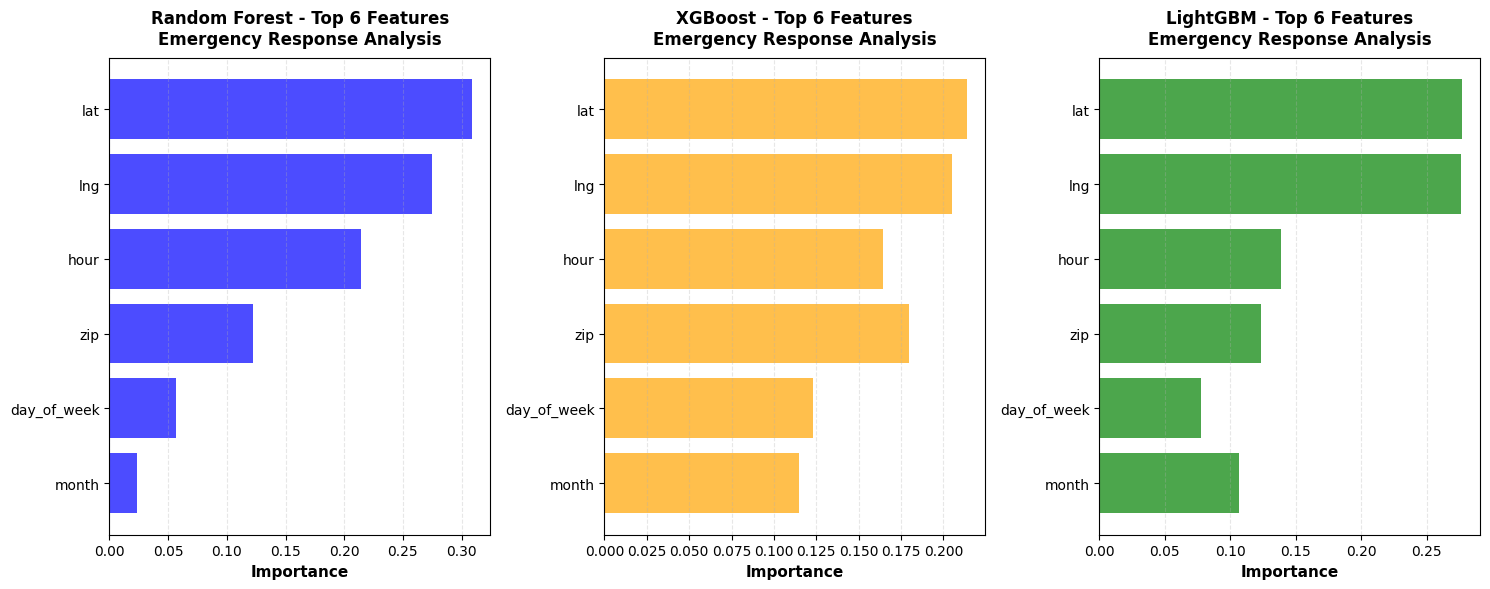


💡 DETAILED INTERPRETATION: Feature Importance

📊 WHAT YOU SEE:
   • Horizontal bar charts showing feature importance for each model
   • Each bar = One feature
   • Bar length = How important that feature is for predictions
   • Features sorted by importance (most important at top)

🔍 HOW TO READ IT:
   • Longer bars = More important features
   • Shorter bars = Less important features
   • Compare across models to see which features matter most
   • Features at top = Most important for emergency category prediction

💡 WHAT THIS TELLS US:
   • Which location/time features are most predictive of emergency type
   • How different models prioritize features
   • Which features to focus on for emergency response optimization

🎯 GDI APPLICATION - Emergency Response:
   • Identify key factors for predicting emergency types
   • Optimize resource allocation based on feature importance
   • Understand which location/time patterns indicate different emergencies
   • Improve emergency response 

In [14]:
# Visualize feature importance
if XGBOOST_AVAILABLE or LIGHTGBM_AVAILABLE:
    # Use actual number of features (we have 6 features, not 10)
    num_features = len(importance_df)
    top_n = min(10, num_features)  # Show top 10 or all features if less than 10
    top_features = importance_df.head(top_n)
    
    # Calculate number of subplots needed
    # Always show Random Forest, plus XGBoost and/or LightGBM if available
    num_plots = 1  # Random Forest
    if XGBOOST_AVAILABLE:
        num_plots += 1
    if LIGHTGBM_AVAILABLE:
        num_plots += 1
    
    # Create subplots
    fig, axes = plt.subplots(1, num_plots, figsize=(5*num_plots, 6))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    idx = 0
    # Random Forest (always shown)
    axes[idx].barh(range(len(top_features)), top_features['Random Forest'].values[::-1], 
                   alpha=0.7, color='blue')
    axes[idx].set_yticks(range(len(top_features)))
    axes[idx].set_yticklabels(top_features['Feature'].values[::-1])
    axes[idx].set_xlabel('Importance', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Random Forest - Top {len(top_features)} Features\nEmergency Response Analysis', fontsize=12, fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, axis='x', linestyle='--')
    idx += 1
    
    # XGBoost (if available)
    if XGBOOST_AVAILABLE:
        axes[idx].barh(range(len(top_features)), top_features['XGBoost'].values[::-1],
                      alpha=0.7, color='orange')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['Feature'].values[::-1])
        axes[idx].set_xlabel('Importance', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'XGBoost - Top {len(top_features)} Features\nEmergency Response Analysis', fontsize=12, fontweight='bold', pad=10)
        axes[idx].grid(True, alpha=0.3, axis='x', linestyle='--')
        idx += 1
    
    # LightGBM (if available)
    if LIGHTGBM_AVAILABLE:
        axes[idx].barh(range(len(top_features)), top_features['LightGBM'].values[::-1],
                      alpha=0.7, color='green')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['Feature'].values[::-1])
        axes[idx].set_xlabel('Importance', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'LightGBM - Top {len(top_features)} Features\nEmergency Response Analysis', fontsize=12, fontweight='bold', pad=10)
        axes[idx].grid(True, alpha=0.3, axis='x', linestyle='--')
        idx += 1
    
    plt.tight_layout()
    plt.savefig('boosting_feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as 'boosting_feature_importance.png'")
    plt.show()
    
    print("\n" + "=" * 70)
    print("💡 DETAILED INTERPRETATION: Feature Importance")
    print("=" * 70)
    print("\n📊 WHAT YOU SEE:")
    print(f"   • Horizontal bar charts showing feature importance for each model")
    print(f"   • Each bar = One feature")
    print(f"   • Bar length = How important that feature is for predictions")
    print(f"   • Features sorted by importance (most important at top)")
    print("\n🔍 HOW TO READ IT:")
    print("   • Longer bars = More important features")
    print("   • Shorter bars = Less important features")
    print("   • Compare across models to see which features matter most")
    print("   • Features at top = Most important for emergency category prediction")
    print("\n💡 WHAT THIS TELLS US:")
    print("   • Which location/time features are most predictive of emergency type")
    print("   • How different models prioritize features")
    print("   • Which features to focus on for emergency response optimization")
    print("\n🎯 GDI APPLICATION - Emergency Response:")
    print("   • Identify key factors for predicting emergency types")
    print("   • Optimize resource allocation based on feature importance")
    print("   • Understand which location/time patterns indicate different emergencies")
    print("   • Improve emergency response planning using feature insights")


---

## ❓ Common Student Questions

**Q: What's the difference between boosting and bagging (Random Forest)?**
- **Answer**: 
  - **Boosting**: Sequential (each model learns from previous mistakes)
    - Model 1 → Model 2 fixes Model 1's mistakes → Model 3 fixes Model 2's mistakes
  - **Bagging (Random Forest)**: Parallel (models trained independently, then averaged)
    - Model 1, Model 2, Model 3 trained independently → average predictions
  - **Performance**: Either can win - depends on data, tuning, and problem type
  - **Boosting**: Can achieve higher accuracy with tuning, but can overfit
  - **Bagging**: More stable, less overfitting, faster training, often works well without tuning
  - **Use boosting**: When you need best performance, have time to tune, willing to risk overfitting
  - **Use bagging**: When you need stability, faster training, less tuning, want reliable baseline

**Q: Why is XGBoost so popular?**
- **Answer**: XGBoost is fast, powerful, and handles many scenarios:
  - **Performance**: Often achieves best results in competitions
  - **Features**: Handles missing values, regularization built-in, feature importance
  - **Usability**: Easy to use, well-documented, widely supported
  - **Industry standard**: Used in production systems worldwide
  - **Rule**: XGBoost is often the first choice for tabular data (structured data)

**Q: What's the difference between XGBoost and LightGBM?**
- **Answer**: 
  - **XGBoost**: Level-wise tree growth (grows all leaves at same level), more stable
  - **LightGBM**: Leaf-wise tree growth (grows best leaves first), faster, uses less memory
  - **Speed**: LightGBM is faster than XGBoost (especially on large datasets)
  - **Memory**: LightGBM uses less memory than XGBoost
  - **Use LightGBM**: Large datasets (> 10k samples), need speed
  - **Use XGBoost**: Smaller datasets, need stability, more features

**Q: Why use boosting instead of just one decision tree?**
- **Answer**: Boosting combines weak learners into strong learner:
  - **Single tree**: Can overfit, limited performance
  - **Boosting**: Many trees combined → less overfitting, better performance
  - **Process**: Each tree corrects previous mistakes → sequential improvement
  - **Result**: Excellent performance (often best among ML algorithms)
  - **Rule**: Boosting > single tree for most problems

**Q: What is learning rate in boosting?**
- **Answer**: Learning rate controls how much each new tree contributes:
  - **Range**: Usually 0.01 to 0.3
  - **Low (0.01)**: Small steps, many trees needed, less overfitting, better performance
  - **High (0.3)**: Large steps, fewer trees needed, can overfit, faster training
  - **Rule of thumb**: Lower learning rate + more trees = better performance (but slower)
  - **Default**: XGBoost/LightGBM default is usually 0.1 (good starting point)

**Q: How many trees (n_estimators) should I use?**
- **Answer**: Balance between performance and training time:
  - **Too few (50-100)**: May underfit, poor performance
  - **Too many (1000+)**: May overfit, slow training, diminishing returns
  - **Good range**: 100-500 trees (depends on learning rate)
  - **Rule**: Lower learning rate → need more trees, higher learning rate → need fewer trees
  - **Tip**: Use early stopping to find optimal number automatically

**Q: Can boosting handle missing values?**
- **Answer**: **Yes!** XGBoost and LightGBM handle missing values automatically:
  - **XGBoost**: Learns best way to handle missing values during training
  - **LightGBM**: Also handles missing values automatically
  - **Advantage**: No need to impute missing values (unlike many other algorithms)
  - **Rule**: Boosting algorithms are robust to missing values
  - **Note**: Still good practice to check for missing values, but not required

**Q: When should I use boosting vs other algorithms?**
- **Answer**: 
  - **Use boosting**: Tabular data (structured data), need best performance, have time to tune
  - **Use Random Forest**: Need fast training, less tuning, more stability
  - **Use Logistic Regression**: Need interpretability, fast predictions, linear patterns
  - **Use Neural Networks**: Image/text data, very large datasets, complex patterns
  - **Rule**: Boosting is often best for tabular data, but try multiple algorithms

---

## ⚠️ Where this breaks

- **Boosting fits the residuals, so it will happily fit label noise.** The eight-point train/test gap
  above is that, in miniature. It needs early stopping against a validation set, and that validation
  set is then no longer available for honest reporting — plan for three splits, not two.
- **It is sequential by construction.** Trees cannot be built in parallel the way a random forest's
  can, which matters when the retraining window is fixed.
- **There are many more knobs.** Learning rate, depth, subsample, colsample, regularisation terms,
  number of rounds — and they interact. A random forest with defaults got within 3.5 points here with
  none of that.
- **The honest limit on this dataset is upstream of every algorithm.** 53–57% against a 50.5% majority
  class means the features — latitude, longitude, ZIP, hour, day-of-week, month — barely determine
  whether a call is EMS, Fire or Traffic. No boosting library fixes a feature set that does not carry
  the signal; the call *text* does, and Unit 3's Naive Bayes lesson reaches 93% using it.
- **The assumption that must hold:** your rows are i.i.d. samples of what you will see later. These
  are calls ordered in time; a proper evaluation would train on earlier months and test on later ones,
  and would score lower than what is printed above.
- **The cheaper alternative:** Random Forest with defaults, when the dataset is small, the labels are
  noisy, or nobody will be available to babysit early stopping.


## Step 7: Decision Framework - Boosting Algorithm Selection

**BEFORE**: You've learned XGBoost and LightGBM, but when should you use each boosting algorithm?

**AFTER**: You'll have a clear decision framework to choose between XGBoost, LightGBM, AdaBoost, and Gradient Boosting!

**Why this matters**: Using the wrong boosting algorithm can:
- **Poor performance** → Wrong algorithm may not fit your data well
- **Wasted computation** → Using slow algorithms when fast ones work
- **Wrong complexity** → Using complex algorithms when simple ones work

---

### 🎯 Decision Framework: Which Boosting Algorithm?

**Key Question**: Should I use **XGBOOST**, **LIGHTGBM**, **ADABOOST**, or **GRADIENT BOOSTING**?

#### Decision Tree:

```
What type of problem do you have?
├─ REGRESSION → Use boosting regressors (XGBoost, LightGBM, Gradient Boosting)
│   └─ Why? All boosting algorithms support regression
│
└─ CLASSIFICATION → Check requirements:
    ├─ Need best performance? → Use XGBOOST or LIGHTGBM ✅
    │   └─ Why? State-of-the-art performance
    │
    ├─ Need speed? → Use LIGHTGBM ✅
    │   └─ Why? LightGBM is fastest
    │
    ├─ Need interpretability? → Use ADABOOST or GRADIENT BOOSTING ✅
    │   └─ Why? Simpler, more interpretable
    │
    ├─ Large dataset (>100k)? → Use LIGHTGBM ✅
    │   └─ Why? LightGBM handles large data efficiently
    │
    └─ Small dataset (<10k)? → Use XGBOOST or ADABOOST ✅
        └─ Why? Both work well on smaller data
```

#### Detailed Decision Process:

```
Step 1: Problem Type
├─ Regression → Continue to Step 2
└─ Classification → Continue to Step 2

Step 2: Dataset Size
├─ Large (>100,000 samples) → Use LIGHTGBM ✅
│   └─ Why? LightGBM is fastest, handles large data best
│
├─ Medium (10,000-100,000) → Continue to Step 3
└─ Small (<10,000) → Continue to Step 3

Step 3: Performance vs Speed
├─ Need best performance? → Use XGBOOST ✅
│   └─ Why? XGBoost often has best accuracy
│
├─ Need speed? → Use LIGHTGBM ✅
│   └─ Why? LightGBM is fastest
│
└─ Need balance? → Continue to Step 4

Step 4: Interpretability
├─ Need interpretability? → Use ADABOOST or GRADIENT BOOSTING ✅
│   └─ Why? Simpler, easier to understand
│
└─ Don't need interpretability? → Use XGBOOST or LIGHTGBM ✅
    └─ Why? Best performance, more complex
```

---

### 📊 Comparison Table: Boosting Algorithms

| Algorithm | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **XGBoost** | Best performance, competitions, medium-large data | • State-of-the-art performance<br>• Robust<br>• Feature importance<br>• Handles missing values | • Slower than LightGBM<br>• More memory<br>• Complex | Kaggle competitions, best accuracy needed |
| **LightGBM** | Large datasets, need speed, good performance | • Fastest<br>• Low memory<br>• Good performance<br>• Handles large data | • May overfit on small data<br>• Less robust than XGBoost | Large datasets, need speed |
| **AdaBoost** | Small datasets, interpretable, simple | • Simple<br>• Interpretable<br>• Works well on small data<br>• Fast | • May not be best performance<br>• Sensitive to outliers | Small datasets, need simplicity |
| **Gradient Boosting** | Medium datasets, interpretable, balanced | • Balanced performance<br>• Interpretable<br>• Good default | • Slower than XGBoost/LightGBM<br>• May not be best | Medium datasets, balanced needs |

---

### ✅ When to Use Each Algorithm

#### Use XGBoost when:
1. **Best Performance Needed** ✅
   - Need state-of-the-art accuracy
   - Competitions, critical applications
   - **Example**: Kaggle competitions, production systems needing best accuracy

2. **Medium to Large Datasets** ✅
   - 10,000-1,000,000 samples
   - XGBoost works well
   - **Example**: Most real-world datasets

3. **Robustness Important** ✅
   - Need robust model
   - XGBoost handles many edge cases
   - **Example**: Production systems, need reliability

4. **Feature Importance Needed** ✅
   - Need to understand feature importance
   - XGBoost provides good feature importance
   - **Example**: Understanding which features matter

#### Use LightGBM when:
1. **Large Datasets** ✅
   - More than 100,000 samples
   - LightGBM is fastest
   - **Example**: Big data, millions of samples

2. **Speed Critical** ✅
   - Need fast training and prediction
   - LightGBM is fastest boosting algorithm
   - **Example**: Real-time systems, quick iterations

3. **Memory Constraints** ✅
   - Limited memory available
   - LightGBM uses less memory
   - **Example**: Limited RAM, large datasets

4. **Good Performance + Speed** ✅
   - Need good performance but also speed
   - LightGBM balances both
   - **Example**: Production systems needing speed

#### Use AdaBoost when:
1. **Small Datasets** ✅
   - Less than 10,000 samples
   - AdaBoost works well on small data
   - **Example**: Small research datasets

2. **Interpretability Needed** ✅
   - Need to understand the model
   - AdaBoost is simpler, more interpretable
   - **Example**: Need to explain decisions

3. **Simple Solution** ✅
   - Want simple, straightforward model
   - AdaBoost is simplest boosting algorithm
   - **Example**: Quick prototyping, simple problems

#### Use Gradient Boosting when:
1. **Balanced Needs** ✅
   - Need balance of performance and interpretability
   - Gradient Boosting is balanced
   - **Example**: Medium datasets, need good performance

2. **Medium Datasets** ✅
   - 1,000-100,000 samples
   - Gradient Boosting works well
   - **Example**: Most business datasets

3. **Good Default** ✅
   - Need a good default boosting algorithm
   - Gradient Boosting is reliable
   - **Example**: Starting point, baseline

---

### ❌ When NOT to Use Each Algorithm

#### Don't use XGBoost when:
1. **Very Large Datasets** ❌
   - More than 1,000,000 samples
   - XGBoost is slower
   - **Use Instead**: LightGBM (faster)

2. **Speed Critical** ❌
   - Need very fast training
   - XGBoost is slower
   - **Use Instead**: LightGBM

3. **Small Datasets** ❌
   - Less than 1,000 samples
   - May overfit
   - **Use Instead**: AdaBoost or simpler models

#### Don't use LightGBM when:
1. **Small Datasets** ❌
   - Less than 10,000 samples
   - May overfit
   - **Use Instead**: XGBoost or AdaBoost

2. **Need Best Accuracy** ❌
   - Need absolute best performance
   - XGBoost often better
   - **Use Instead**: XGBoost

#### Don't use AdaBoost when:
1. **Large Datasets** ❌
   - More than 100,000 samples
   - AdaBoost is slow
   - **Use Instead**: XGBoost or LightGBM

2. **Best Performance Needed** ❌
   - Need state-of-the-art accuracy
   - AdaBoost may not be best
   - **Use Instead**: XGBoost or LightGBM

#### Don't use Gradient Boosting when:
1. **Best Performance Needed** ❌
   - Need absolute best accuracy
   - XGBoost/LightGBM usually better
   - **Use Instead**: XGBoost or LightGBM

2. **Speed Critical** ❌
   - Need fast training
   - Gradient Boosting is slower
   - **Use Instead**: LightGBM

---

### 📊 Real-World Examples

#### Example 1: Kaggle Competition ✅ XGBOOST
- **Problem**: Classification competition
- **Dataset**: Medium (50,000 samples)
- **Need**: Best performance (winning competition)
- **Decision**: ✅ Use XGBoost
- **Reasoning**: Need best performance, medium dataset, XGBoost often wins

#### Example 2: Large-Scale Customer Segmentation ✅ LIGHTGBM
- **Problem**: Segment 1,000,000 customers
- **Dataset**: Large (1,000,000 samples)
- **Need**: Speed and good performance
- **Decision**: ✅ Use LightGBM
- **Reasoning**: Large dataset, need speed, LightGBM handles large data best

#### Example 3: Small Medical Dataset ✅ ADABOOST
- **Problem**: Diagnose disease from 500 patients
- **Dataset**: Small (500 samples)
- **Need**: Interpretability and simplicity
- **Decision**: ✅ Use AdaBoost
- **Reasoning**: Small dataset, need interpretability, AdaBoost works well

#### Example 4: Medium Business Dataset ✅ XGBOOST or GRADIENT BOOSTING
- **Problem**: Predict customer churn
- **Dataset**: Medium (20,000 samples)
- **Need**: Good performance, balanced
- **Decision**: ✅ Use XGBoost (or Gradient Boosting)
- **Reasoning**: Medium dataset, need good performance, both work well

---

### ✅ Key Takeaways

1. **Best performance → XGBoost** - Use for competitions and best accuracy
2. **Large data + speed → LightGBM** - Use for large datasets needing speed
3. **Small data → AdaBoost** - Use for small datasets, interpretability
4. **Balanced → Gradient Boosting** - Use for balanced needs
5. **Try multiple** - Often try XGBoost and LightGBM, pick the best
6. **Tune hyperparameters** - All boosting algorithms need tuning
7. **Feature importance** - All provide feature importance

---

### 🎓 Practice Decision-Making

**Scenario 1**: Kaggle competition with 30,000 samples
- **Dataset**: Medium (30,000)
- **Need**: Best performance (winning)
- **Decision**: ✅ XGBoost (best performance, medium dataset)

**Scenario 2**: Real-time fraud detection with 500,000 transactions
- **Dataset**: Large (500,000)
- **Need**: Speed and good performance
- **Decision**: ✅ LightGBM (large dataset, need speed)

**Scenario 3**: Medical diagnosis with 800 patients
- **Dataset**: Small (800)
- **Need**: Interpretability
- **Decision**: ✅ AdaBoost (small dataset, need interpretability)

---

**Connection to Next Steps**: 
- 📓 **Example 1: Grid Search** - For tuning boosting hyperparameters
- 📓 **All ML Projects** - Boosting algorithms are powerful tools
- 📓 **Production Systems** - Choose algorithm based on your needs


6. Confusion Matrices Comparison

💡 Transition: Let's visualize how well each model classifies emergency types!
   Note: ROC curves are for binary classification only.
   For multi-class (3 classes: EMS, Fire, Traffic), we use confusion matrices instead!



✓ Plot saved as 'boosting_confusion_matrices.png'


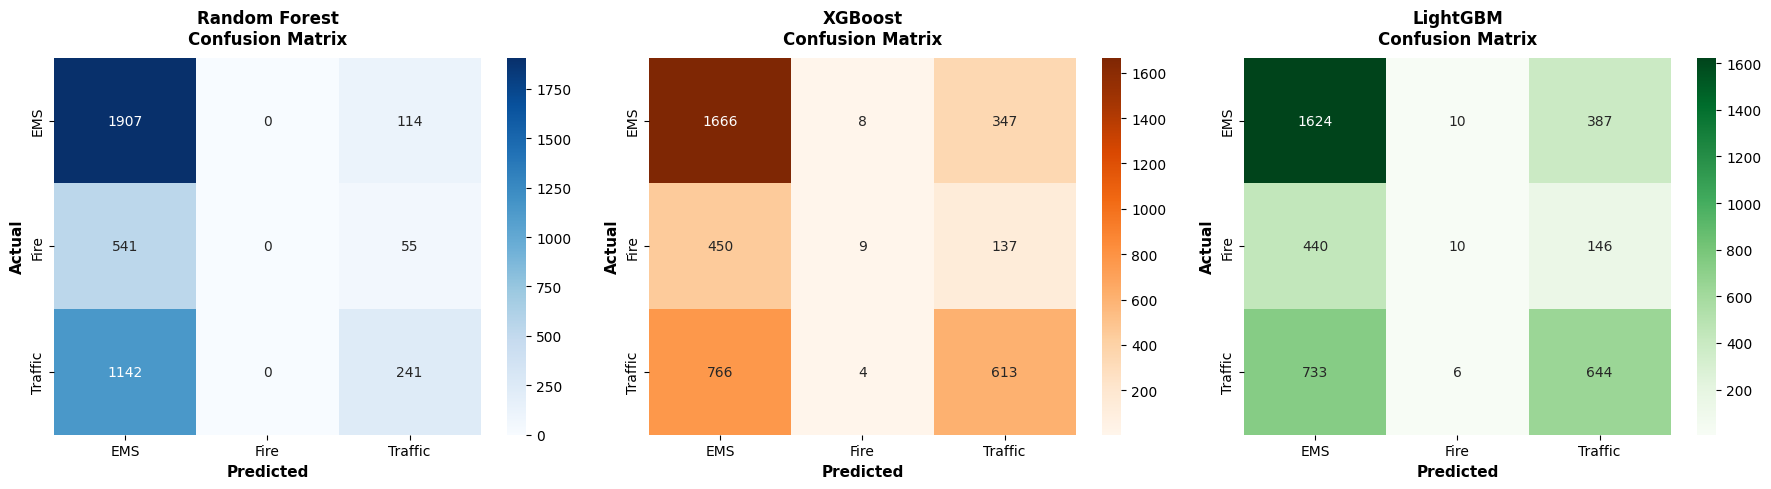


💡 DETAILED INTERPRETATION: Confusion Matrices (Multi-class)

📊 WHAT YOU SEE:
   • Heatmaps showing confusion matrices for each model
   • Each cell = Number of predictions
   • Rows = Actual emergency categories (EMS, Fire, Traffic)
   • Columns = Predicted emergency categories

🔍 HOW TO READ IT:
   • Diagonal cells (top-left to bottom-right) = Correct predictions
   • Off-diagonal cells = Incorrect predictions
   • Darker colors = More predictions
   • Perfect model = All values on diagonal, zeros elsewhere

💡 WHAT THIS TELLS US:
   • Which emergency types are predicted correctly most often
   • Which emergency types are confused with each other
   • Overall model performance for each emergency category

🎯 GDI APPLICATION - Emergency Response:
   • Understand which emergency types are easiest/hardest to predict
   • Identify patterns in misclassifications (e.g., Fire vs Traffic)
   • Optimize emergency response based on prediction accuracy
   • Improve resource allocation using class


✓ Plot saved as 'xgb_learning_curve.png'


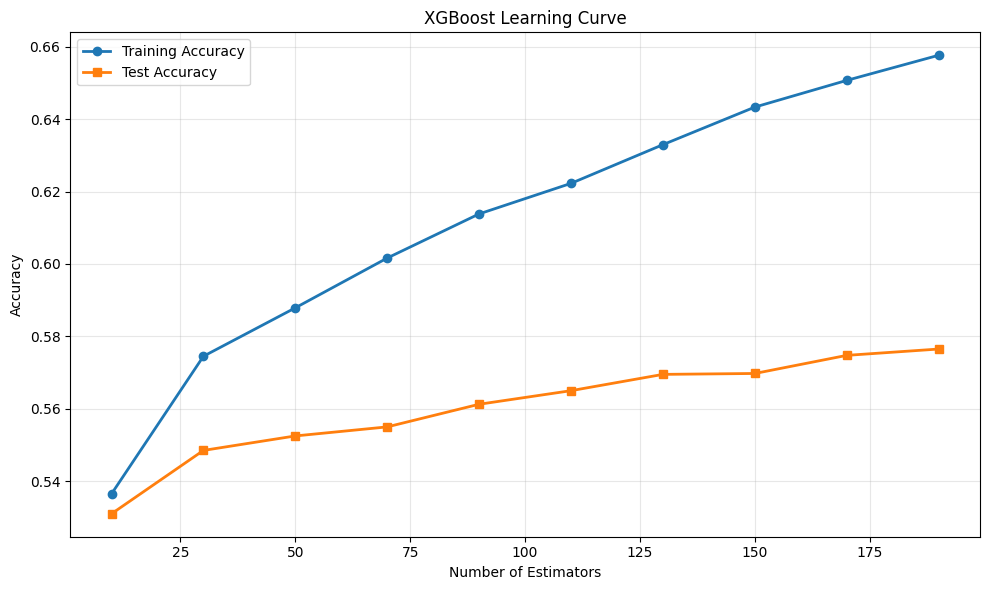


Example 2 Complete! ✓


In [15]:
# 6. Confusion Matrices Comparison (Multi-class Classification)
print("\n" + "=" * 60)
print("6. Confusion Matrices Comparison")
print("=" * 60)
print("\n💡 Transition: Let's visualize how well each model classifies emergency types!")
print("   Note: ROC curves are for binary classification only.")
print("   For multi-class (3 classes: EMS, Fire, Traffic), we use confusion matrices instead!")

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_rf = rf.predict(X_test)
if XGBOOST_AVAILABLE:
    y_pred_xgb = xgb_model.predict(X_test)
if LIGHTGBM_AVAILABLE:
    y_pred_lgb = lgb_model.predict(X_test)

# Calculate number of subplots
num_plots = 1  # Random Forest
if XGBOOST_AVAILABLE:
    num_plots += 1
if LIGHTGBM_AVAILABLE:
    num_plots += 1

# Create subplots
fig, axes = plt.subplots(1, num_plots, figsize=(6*num_plots, 5))
if not isinstance(axes, np.ndarray):
    axes = [axes]

# Get category names for labels
if 'category_names' in globals():
    class_names = category_names
else:
    class_names = ['EMS', 'Fire', 'Traffic']  # Default fallback

idx = 0
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
            xticklabels=class_names, yticklabels=class_names)
axes[idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
axes[idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[idx].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
idx += 1

# XGBoost
if XGBOOST_AVAILABLE:
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
    axes[idx].set_title('XGBoost\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
    idx += 1

# LightGBM
if LIGHTGBM_AVAILABLE:
    cm_lgb = confusion_matrix(y_test, y_pred_lgb)
    sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
    axes[idx].set_title('LightGBM\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
    idx += 1

plt.tight_layout()
plt.savefig('boosting_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'boosting_confusion_matrices.png'")
plt.show()

print("\n" + "=" * 70)
print("💡 DETAILED INTERPRETATION: Confusion Matrices (Multi-class)")
print("=" * 70)
print("\n📊 WHAT YOU SEE:")
print(f"   • Heatmaps showing confusion matrices for each model")
print(f"   • Each cell = Number of predictions")
print(f"   • Rows = Actual emergency categories ({', '.join(class_names)})")
print(f"   • Columns = Predicted emergency categories")
print("\n🔍 HOW TO READ IT:")
print("   • Diagonal cells (top-left to bottom-right) = Correct predictions")
print("   • Off-diagonal cells = Incorrect predictions")
print("   • Darker colors = More predictions")
print("   • Perfect model = All values on diagonal, zeros elsewhere")
print("\n💡 WHAT THIS TELLS US:")
print("   • Which emergency types are predicted correctly most often")
print("   • Which emergency types are confused with each other")
print("   • Overall model performance for each emergency category")
print("\n🎯 GDI APPLICATION - Emergency Response:")
print("   • Understand which emergency types are easiest/hardest to predict")
print("   • Identify patterns in misclassifications (e.g., Fire vs Traffic)")
print("   • Optimize emergency response based on prediction accuracy")
print("   • Improve resource allocation using classification insights")

# 7. Learning Curve (XGBoost)
print("\n" + "=" * 60)
print("7. Learning Curve Example (XGBoost)")
print("=" * 60)
print("\n💡 Transition: Let's see how XGBoost performance changes with more trees!")
print("   This helps us understand the relationship between model complexity and performance.")
if XGBOOST_AVAILABLE:
    # Train with different number of estimators
    n_estimators_range = range(10, 201, 20)
    train_scores = []
    test_scores = []
    for n_est in n_estimators_range:
        xgb_temp = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5,
            learning_rate=0.1,
            random_state=73,  # Using 73 for consistency
            eval_metric='logloss'
        )
        xgb_temp.fit(X_train, y_train)
        train_scores.append(accuracy_score(y_train, xgb_temp.predict(X_train)))
        test_scores.append(accuracy_score(y_test, xgb_temp.predict(X_test)))
    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_range, train_scores, 'o-', label='Training Accuracy', linewidth=2)
    plt.plot(n_estimators_range, test_scores, 's-', label='Test Accuracy', linewidth=2)
    plt.xlabel('Number of Estimators')
    plt.ylabel('Accuracy')
    plt.title('XGBoost Learning Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('xgb_learning_curve.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as 'xgb_learning_curve.png'")
    plt.show()

print("\n" + "=" * 60)
print("Example 2 Complete! ✓")
print("=" * 60)
if not XGBOOST_AVAILABLE or not LIGHTGBM_AVAILABLE:
    print("\nNote: Install missing packages for full functionality:")
    if not XGBOOST_AVAILABLE:
        print("  pip install xgboost")
    if not LIGHTGBM_AVAILABLE:
        print("  pip install lightgbm")

## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

Gradient boosting is still the correct default on tabular data, for the reason this unit teaches: trees
cope with heterogeneous columns, uninformative features and non-smooth targets in a way generic deep
models do not (Grinsztajn et al., 2022, arXiv:2207.08815). Since late 2025 it has, for the first time,
a serious competitor of a different kind — tabular foundation models, pretrained once on synthetic data
and then doing in-context prediction on your table with no per-dataset training (the idea starts with
Hollmann et al., 2022, arXiv:2207.01848). TabPFN-2.5's authors report that it leads the TabArena
benchmark, outperforms tuned tree-based models, matches a four-hour tuned AutoGluon ensemble, and wins
100% of head-to-heads against default XGBoost on classification datasets up to 10,000 rows and 500
features (Grinsztajn et al., 2025, arXiv:2511.08667); TabPFN-3 extends the approach to a million
training rows and reports beating eight-hour-tuned GBDT baselines with one forward pass (Grinsztajn et
al., 2026, arXiv:2605.13986). Read those as authors' reported benchmark numbers, not a verdict: they
come from the models' own teams, the models need downloaded pretrained weights and a GPU at the larger
sizes, and none of it runs in this offline lab — which is precisely why this notebook trains XGBoost and
LightGBM on a CPU instead. What it changes in your workflow is one line: benchmark a tabular foundation
model *against* your tuned booster before concluding the booster is the ceiling — and note that
TabPFN-2.5 ships a distillation step back to a compact MLP or tree ensemble, because production still
wants something small, fast and deployable. Keep boosting: it is the mechanism, it is the baseline every
one of these papers measures against, it runs on the hardware you have, and it is what the official plan
examines; if you want to see inside a tabular foundation model, nanoTabPFN is a deliberately small,
educational reimplementation (Pfefferle et al., 2025, arXiv:2511.03634).

## 📚 References

1. Freund, Y., & Schapire, R. E. (1997). *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*. Journal of Computer and System Sciences, 55(1), 119–139.
2. Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics, 29(5), 1189–1232.
3. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016. <https://arxiv.org/abs/1603.02754>
4. Ke, G., et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS 30.
5. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
6. Hollmann, N., Müller, S., Eggensperger, K., & Hutter, F. (2022). *TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second*. <https://arxiv.org/abs/2207.01848>
7. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. <https://arxiv.org/abs/2511.08667>
8. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. <https://arxiv.org/abs/2605.13986>
9. Pfefferle, A., Hog, J., Purucker, L., & Hutter, F. (2025). *nanoTabPFN: A Lightweight and Educational Reimplementation of TabPFN*. <https://arxiv.org/abs/2511.03634>
